### Swiggy sales Analysis

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [23]:
df = pd.read_excel(r"swiggy_data.xlsx")

In [24]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [28]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [29]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


<h3>Metadata</h3>

In [30]:
print("No.Of rows: ",df.shape[0])

No.Of rows:  197430


In [31]:
print("No.Of Fields: ",df.shape[1])

No.Of Fields:  10


<h3>Data Types</h3>

In [32]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [33]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


<H2>KPI'S</h2>

<h3>Total Sales</h3>

In [34]:
total_sales = df["Price (INR)"].sum()
print("Total number of Sales: ",round(total_sales,2))

Total number of Sales:  53012505.77


<h3>Average Rating</h3>

In [35]:
avg_rating = df["Rating"].mean()
print("Average Rating: ",round(avg_rating,1))

Average Rating:  4.3


<h3>Average Order value</h3>

In [36]:
avg_order_value = df["Price (INR)"].mean()
print("Average Order Value is: ",round(avg_order_value,2))

Average Order Value is:  268.51


<h3>Ratings count</h3>

In [37]:
rating_count = df["Rating Count"].sum()
print("Ratings Count: ",round(rating_count,2))

Ratings Count:  5591574


<h3>Total orders</h3>

In [38]:
total_order = len(df)
print("Total Orders: ", total_order)

Total Orders:  197430


<H2>Monthly Sales trend</h2>

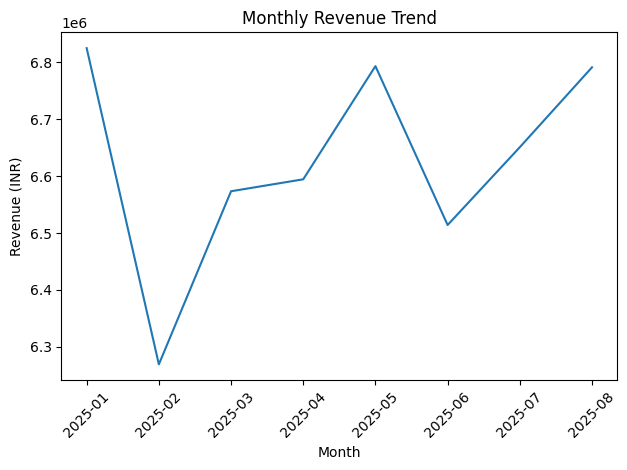

In [39]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()
plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()


<h3>Daily Revenue Trend</h3>

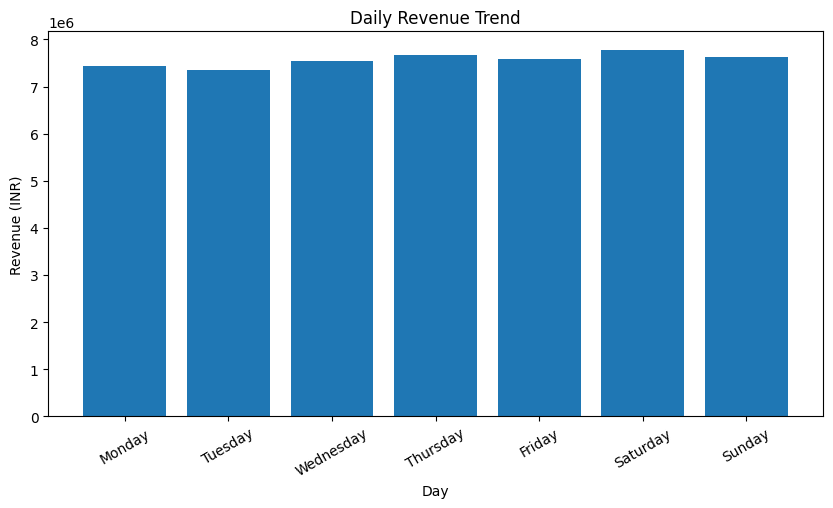

In [40]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = df.groupby("DayName")["Price (INR)"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.title("Daily Revenue Trend")
plt.xticks(rotation=30)
    
plt.show()

<h3>Total Sales by Food Type (Veg or Non-Veg)</h3>

In [45]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabak",
    "non-veg"
]

pattern = "|".join(non_veg_keywords)

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains(pattern, na=False),
    "Non-Veg",
    "Veg"
)

In [46]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

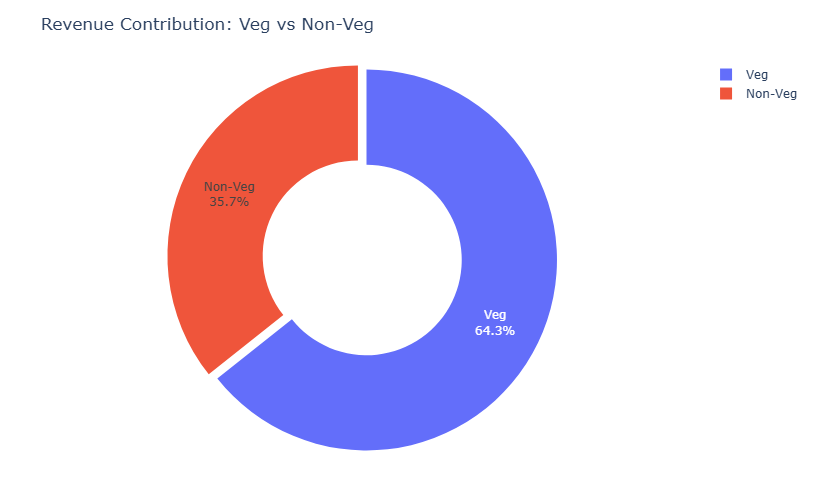

In [51]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]   # Correct syntax
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40),
)

fig.show()

<h3>Total Sales BY State</h3>

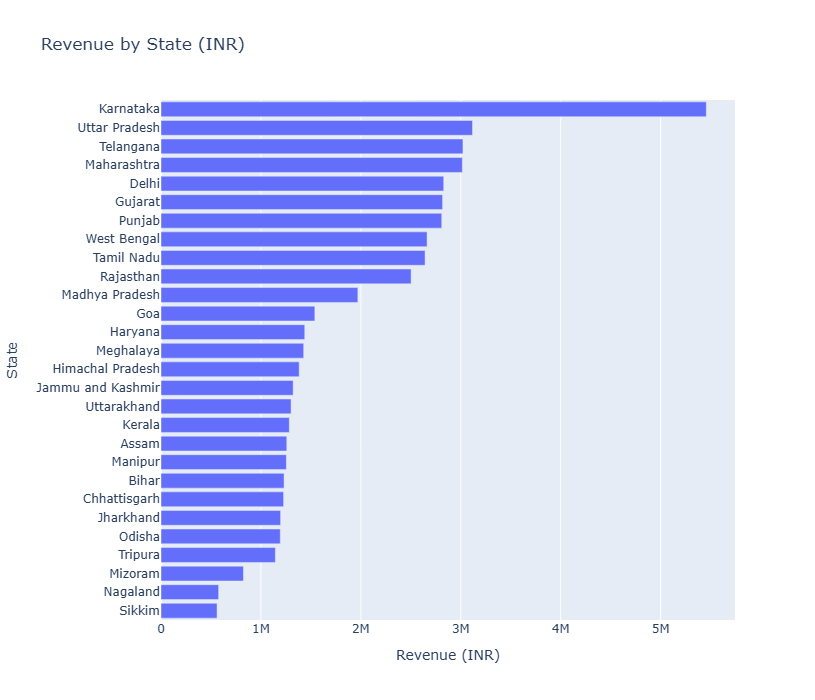

In [56]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
      .sort_values("Price (INR)", ascending=True),    # ascending → smallest at top (classic horizontal)
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)

fig.update_layout(
    height=700,
    xaxis_title="Revenue (INR)",
    yaxis_title="State",
)

fig.show()

<H3>Quaterely performance Summary</h3>

In [59]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price (INR)", "sum"),
          Avg_rating=("Rating", "mean"),
          Total_orders=("Order_Date", "count")
      )
      .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_rating"] = quarterly_summary["Avg_rating"].round(2)

quarterly_summary
    

,Quarter,Total_Sales,Avg_rating,Total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


<h3>Top 5 cities By Sales</h3>

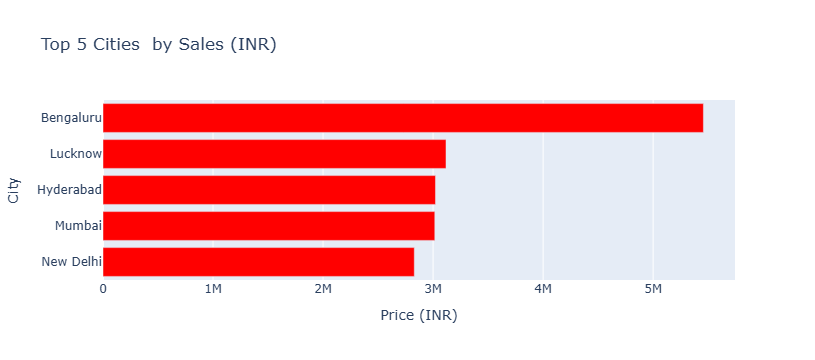

In [60]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)
fig =px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities  by Sales (INR)",
    color_discrete_sequence=["red"]
)
fig.show()
    
    